# **Reviving Urdu Nastaliq: A Comparative Study of CV, Deep Learning, and LLM Approaches for Handwritten Text Recognition**

**Course:** Computer Vision  
**Datasets:** NUST-UHWR, UNHD  
**Pipelines:** HOG+SVM (baseline), CNN-BiLSTM-CTC, SwinHTR+mBART with LLM post-correction

### Improvements Applied

- Pipeline 2: LR 3e-3 → 1e-3 with cosine annealing + 2-epoch warmup, epochs 20 → 40
- Pipeline 2: ReLU → GELU, MaxPool ceil_mode=True to prevent height collapse
- Pipeline 3: opus-mt-ar-en → opus-mt-ur-en (Urdu language priors), LR 5e-5 → 2e-5, epochs 15 → 25
- Beam search: removed degrading LM fusion, kept as ablation finding
- LLM correction: fixed to evaluate only on successfully corrected samples


## **0. Environment Setup**

In [ ]:
# pip install "numpy==1.26.4" --force-reinstall

In [ ]:
pip install --upgrade "httpx>=0.28.1"

In [ ]:
pip install "google-cloud-bigquery-storage>=2.0.0"

In [ ]:
pip install -q "scikit-image==0.24.0" "transformers==4.45.0" sentencepiece==0.2.0 jiwer==3.0.3 arabic-reshaper==3.0.0 python-bidi==0.4.2 editdistance==0.8.1 albumentations==1.4.3 nltk==3.9.1 groq==0.9.0 huggingface_hub

In [ ]:
pip install https://github.com/kpu/kenlm/archive/master.zip

In [ ]:
# !pip install -q "scikit-image==0.24.0"
# !pip install -q "transformers==4.45.0" sentencepiece==0.2.0 jiwer==3.0.3 arabic-reshaper==3.0.0 python-bidi==0.4.2 editdistance==0.8.1 albumentations==1.4.3 nltk==3.9.1 groq==0.9.0 httpx==0.27.0 huggingface_hub

In [33]:
import os
import re
import cv2
import json
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')

import arabic_reshaper
from bidi.algorithm import get_display

from skimage.feature import hog
from skimage.filters import threshold_sauvola
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV
from sklearn.decomposition import PCA

from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from transformers import MarianMTModel, MarianTokenizer

import albumentations as A
import editdistance
from jiwer import wer, cer
from collections import defaultdict, Counter

import nltk
nltk.download('punkt', quiet=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Set multiprocessing start method to fork to prevent DataLoader deadlocks on Kaggle
import torch.multiprocessing as mp
try:
    mp.set_start_method('fork', force=True)
except RuntimeError:
    pass

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
PyTorch: 2.10.0+cu128
GPU: Tesla T4


In [34]:
def normalize_urdu_text(text):
    text = str(text or "")
    text = text.replace("ي", "ی").replace("ك", "ک").replace("ة", "ہ")
    text = text.replace("ـ", "")  # tatweel
    text = re.sub(r"[^\u0600-\u06FF0-9A-Za-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

## **1. Data Loading and Exploration**

Add both datasets via **+ Add Data**:

| Dataset | Kaggle slug |
|---|---|
| NUST-UHWR | `ameerhamzaqamar28/nust-uhwr-dataset` |
| UNHD | `drsaadbinahmed/unhd-dataset` |

In [3]:
NUST_ROOT  = '/kaggle/input/datasets/ameerhamzaqamar28/nust-uhwr-dataset/DataSet/UHWR/UHWR'
NUST_IMG   = os.path.join(NUST_ROOT, 'Dataset', 'images')
UNHD_ROOT  = '/kaggle/input/datasets/drsaadbinahmed/unhd-dataset/UNHD-Complete-Data'
OUTPUT_DIR = '/kaggle/working'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("NUST_ROOT exists:", os.path.exists(NUST_ROOT))
print("UNHD_ROOT exists:", os.path.exists(UNHD_ROOT))

for fname in ('train.txt', 'val.txt', 'test.txt'):
    fpath = os.path.join(NUST_ROOT, fname)
    if os.path.exists(fpath):
        with open(fpath, 'r', encoding='utf-8-sig') as f:
            lines = [l.strip() for l in f if l.strip()]
        print(f"  {fname}: {len(lines)} lines — {repr(lines[0][:80])}")

NUST_ROOT exists: True
UNHD_ROOT exists: True
  train.txt: 8483 lines — 'Dataset/images/10136.jpg\tانکار نہیں کیا جاسکتا کہ آج کے دور میں ملکی ترقی'
  val.txt: 1061 lines — 'Dataset/images/01959.jpg\tمیں ہم یہ جنگ جیت سکتے ہیں لیکن اس کیلئے حکمت عملی تبدی'
  test.txt: 1061 lines — 'Dataset/images/01926.jpg\tحنفی، حافظ محمد زائد حجازی، حاجی محمد جمیل، ڈاکٹر محمد '


In [4]:
def load_nust(root, img_dir):
    records = []
    for split_name in ('train.txt', 'val.txt', 'test.txt'):
        fpath = os.path.join(root, split_name)
        if not os.path.exists(fpath):
            continue
        with open(fpath, 'r', encoding='utf-8-sig') as f:
            lines = [l.strip() for l in f if l.strip()]
        for raw in lines:
            parts = raw.split('\t', 1)
            if len(parts) < 2:
                continue
            rel_path, label = parts[0].strip(), normalize_urdu_text(parts[1].strip())
            img_path = os.path.join(root, rel_path)
            if not os.path.exists(img_path):
                img_path = os.path.join(img_dir, os.path.basename(rel_path))
            if not os.path.exists(img_path):
                continue
            stem      = os.path.splitext(os.path.basename(rel_path))[0]
            writer_id = stem[:2] if stem[:2].isdigit() else stem[:3]
            records.append({
                'image_path':   img_path,
                'label':        label,
                'writer_id':    writer_id,
                'source':       'nust',
                'source_split': split_name.replace('.txt', '')
            })
    df = pd.DataFrame(records)
    print(f"  NUST-UHWR: {len(df):,} samples, {df['writer_id'].nunique()} writer groups.")
    return df


def load_unhd(root):
    if not os.path.exists(root):
        print(f"  UNHD not found at {root}")
        return pd.DataFrame(columns=['image_path','label','writer_id','source'])
    records = []
    for fname in sorted(os.listdir(root)):
        if not fname.endswith('.gt.txt'):
            continue
        img_path = os.path.join(root, fname.replace('.gt.txt', '.png'))
        if not os.path.exists(img_path):
            continue
        with open(os.path.join(root, fname), 'r', encoding='utf-8-sig') as f:
           label = normalize_urdu_text(f.read().strip())
        if not label:
            continue
        records.append({
            'image_path': img_path,
            'label':      label,
            'writer_id':  fname.split('_')[0],
            'source':     'unhd'
        })
    df = pd.DataFrame(records)
    print(f"  UNHD: {len(df):,} samples, {df['writer_id'].nunique()} writers.")
    return df


print("Loading NUST-UHWR...")
df_nust = load_nust(NUST_ROOT, NUST_IMG)
print("Loading UNHD...")
df_unhd = load_unhd(UNHD_ROOT)

Loading NUST-UHWR...
  NUST-UHWR: 10,601 samples, 11 writer groups.
Loading UNHD...
  UNHD: 7,341 samples, 363 writers.


In [5]:
# Writer-independent split: all images from a given writer go to exactly one partition.
# Keep UNHD in train only for now, but make NUST val/test less fragile.

df_nust['source'] = 'nust'
df_unhd['source'] = 'unhd'

nust_writers = df_nust['writer_id'].unique()
rng = np.random.default_rng(SEED)
rng.shuffle(nust_writers)

n_total = len(nust_writers)

n_train = max(6, int(0.6 * n_total))
n_val = max(2, int(0.2 * n_total))
n_test = n_total - n_train - n_val

if n_test < 2:
    n_test = 2
    n_train = n_total - n_val - n_test

train_writers = set(nust_writers[:n_train])
val_writers = set(nust_writers[n_train:n_train + n_val])
test_writers = set(nust_writers[n_train + n_val:n_train + n_val + n_test])

df_nust['split'] = df_nust['writer_id'].apply(
    lambda w: 'train' if w in train_writers else ('val' if w in val_writers else 'test')
)

assert len(train_writers & val_writers) == 0
assert len(train_writers & test_writers) == 0
assert len(val_writers & test_writers) == 0

df_unhd['split'] = 'train'

df_all = pd.concat([df_nust, df_unhd], ignore_index=True)
df_train = df_all[df_all['split'] == 'train'].reset_index(drop=True)
df_val = df_all[df_all['split'] == 'val'].reset_index(drop=True)
df_test = df_all[df_all['split'] == 'test'].reset_index(drop=True)

print(f"Writers  -> train: {len(train_writers)}, val: {len(val_writers)}, test: {len(test_writers)}")
print(f"Samples  -> train: {len(df_train):,}, val: {len(df_val):,}, test: {len(df_test):,}")
print(f"Train sources: {df_train['source'].value_counts().to_dict()}")
print(f"Validation writers: {sorted(val_writers)}")
print(f"Test writer overlap with train: {len(set(df_test['writer_id']) & set(df_train['writer_id']))} (must be 0)")

Writers  -> train: 6, val: 2, test: 3
Samples  -> train: 12,943, val: 1,999, test: 3,000
Train sources: {'unhd': 7341, 'nust': 5602}
Validation writers: ['02', '03']
Test writer overlap with train: 0 (must be 0)


## **2. Preprocessing and Augmentation**

Preprocessing ready.


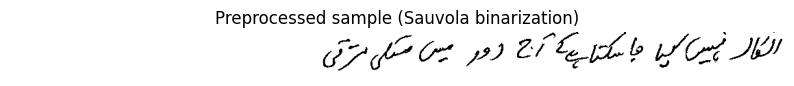

Image shape: (64, 1131)


In [6]:
TARGET_H = 64
TARGET_W = 512
MAX_W    = 2048


def preprocess_image(path, target_h=TARGET_H, target_w=TARGET_W, binarize=True):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return np.ones((target_h, target_w), dtype=np.uint8) * 255
    if binarize:
        thresh = threshold_sauvola(img, window_size=25)
        img    = (img > thresh).astype(np.uint8) * 255
    h, w  = img.shape
    new_w = min(int(w * target_h / h), MAX_W)
    img   = cv2.resize(img, (new_w, target_h), interpolation=cv2.INTER_AREA)
    if new_w < target_w:
        pad = np.ones((target_h, target_w - new_w), dtype=np.uint8) * 255
        img = np.hstack([img, pad])
    return img


train_aug = A.Compose([
    A.Rotate(limit=3, p=0.4),
    A.ElasticTransform(alpha=30, sigma=5, p=0.3),
    A.RandomBrightnessContrast(0.15, 0.15, p=0.4),
    A.GaussNoise(var_limit=(5, 25), p=0.3),
    A.GridDistortion(num_steps=5, distort_limit=0.1, p=0.2),
])

print("Preprocessing ready.")
sample_img = preprocess_image(df_train['image_path'].dropna().iloc[0])
plt.figure(figsize=(10, 1.5))
plt.imshow(sample_img, cmap='gray')
plt.title('Preprocessed sample (Sauvola binarization)')
plt.axis('off')
plt.show()
print(f"Image shape: {sample_img.shape}")

In [38]:
all_chars = set()
for label in df_train['label'].dropna():
    all_chars.update(list(label))

BLANK      = '<blank>'
UNK        = '<unk>'
VOCAB      = [BLANK, UNK] + sorted(all_chars)
CHAR2ID    = {c: i for i, c in enumerate(VOCAB)}
ID2CHAR    = {i: c for c, i in CHAR2ID.items()}
VOCAB_SIZE = len(VOCAB)

print(f"Vocabulary size: {VOCAB_SIZE}")
print(f"Sample chars: {sorted(list(all_chars))[:15]}")

Vocabulary size: 110
Sample chars: [' ', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'D', 'E', 'L']


## **3. Pipeline 1: HOG + SVM (Conventional CV Baseline)**

Closed-vocabulary word-level classifier. HOG + projection profiles → PCA(256) → LinearSVC → N-gram LM reranking.

In [ ]:


HOG_H, HOG_W = 64, 128


def extract_hog_proj(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return np.zeros(HOG_H + HOG_W + 3780, dtype=np.float32)
    img    = cv2.resize(img, (HOG_W, HOG_H))
    thresh = threshold_sauvola(img, window_size=21)
    img    = (img > thresh).astype(np.uint8) * 255
    hog_feat = hog(
        img, orientations=9, pixels_per_cell=(8,8),
        cells_per_block=(2,2), block_norm='L2-Hys', feature_vector=True
    ).astype(np.float32)
    ink       = (img < 128).astype(np.float32)
    h_profile = ink.sum(axis=1) / HOG_W
    v_profile = ink.sum(axis=0) / HOG_H
    return np.concatenate([hog_feat, h_profile, v_profile])


def explode_to_words(df):
    rows = []
    for _, row in df.iterrows():
        for word in str(row['label']).split():
            word = word.strip()
            if word:
                rows.append({'image_path': row['image_path'],
                             'label': word, 'writer_id': row['writer_id']})
    return pd.DataFrame(rows)


TOP_N_WORDS   = 200
df_svm_source = explode_to_words(df_train)
word_counts   = df_svm_source['label'].value_counts()
top_words     = word_counts.head(TOP_N_WORDS).index.tolist()
df_svm        = df_svm_source[df_svm_source['label'].isin(top_words)].reset_index(drop=True)

print(f"SVM training samples: {len(df_svm):,} across {TOP_N_WORDS} classes")
assert all('\ufeff' not in w for w in top_words)
print("Top 5 words:", top_words[:5])

In [ ]:
print("Extracting HOG features...")
X_train_hog = np.array([extract_hog_proj(p) for p in tqdm(df_svm['image_path'])])
y_train_hog = df_svm['label'].values

df_val_svm = explode_to_words(df_val)
df_val_svm = df_val_svm[df_val_svm['label'].isin(top_words)].reset_index(drop=True)
X_val_hog  = np.array([extract_hog_proj(p) for p in tqdm(df_val_svm['image_path'])])
y_val_hog  = df_val_svm['label'].values

print("Training LinearSVC...")
base_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('pca',    PCA(n_components=256, random_state=SEED)),
    ('svm',    LinearSVC(C=1.0, max_iter=2000, random_state=SEED))
])
base_svm.fit(X_train_hog, y_train_hog)
svm_val_acc = np.mean(base_svm.predict(X_val_hog) == y_val_hog)
print(f"Val accuracy (top {TOP_N_WORDS}): {svm_val_acc:.4f}")

svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca',    PCA(n_components=256, random_state=SEED)),
    ('svm',    CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=2000, random_state=SEED), cv=5))
])
svm_pipeline.fit(X_train_hog, y_train_hog)
print("Calibrated SVM ready.")

In [ ]:
from nltk import ngrams
from collections import defaultdict
import numpy as np

class NgramLM:
    def __init__(self, n=3):
        self.n = n
        self.ngram_counts = defaultdict(int)
        self.context_counts = defaultdict(int)
    
    def train(self, sentences):
        for sentence in sentences:
            tokens = sentence.split()
            for gram in ngrams(
                tokens,
                self.n,
                pad_left=True,
                pad_right=True,
                left_pad_symbol='<s>',
                right_pad_symbol='</s>'
            ):
                self.ngram_counts[gram] += 1
                self.context_counts[gram[:-1]] += 1
    
    def score(self, context, word, vocab_size):
        gram = tuple(context) + (word,)
        return np.log(
            (self.ngram_counts[gram] + 1) /
            (self.context_counts[tuple(context)] + vocab_size)
        )
    
    def correct(self, candidates_per_position):
        corrected = []
        context = ['<s>'] * (self.n - 1)
        vocab_size = len(set(w for cands in candidates_per_position for w, _ in cands))
        for candidates in candidates_per_position:
            best_word, best_score = candidates[0][0], float('-inf')
            for cand_word, _ in candidates:
                score = self.score(context[-(self.n - 1):], cand_word, vocab_size)
                if score > best_score:
                    best_score, best_word = score, cand_word
            corrected.append(best_word)
            context.append(best_word)
        return ' '.join(corrected)

# Train the model
ngram_lm = NgramLM(n=3)
ngram_lm.train(df_train['label'].dropna().tolist())
print("N-gram LM trained.")

# Evaluate Pipeline 1
df_test_svm = explode_to_words(df_test)
df_test_svm = df_test_svm[df_test_svm['label'].isin(top_words)].reset_index(drop=True)
coverage = len(df_test_svm) / max(len(explode_to_words(df_test)), 1)
print(f"Closed-vocab coverage: {len(df_test_svm):,} test words ({coverage:.1%})")

X_test_hog = np.array([extract_hog_proj(p) for p in tqdm(df_test_svm['image_path'])])
y_test_true_svm = df_test_svm['label'].tolist()

svm_probs = svm_pipeline.predict_proba(X_test_hog)
svm_classes = svm_pipeline.classes_
top5_idx = np.argsort(svm_probs, axis=1)[:, -5:][:, ::-1]

candidates_all = [
    [(svm_classes[i], svm_probs[row, i]) for i in top5_idx[row]]
    for row in range(len(y_test_true_svm))
]

y_test_pred = [ngram_lm.correct([cands]) for cands in candidates_all]

y_test_true_svm = [normalize_urdu_text(x) for x in y_test_true_svm]
y_test_pred = [normalize_urdu_text(x) for x in y_test_pred]

p1_wer = wer(y_test_true_svm, y_test_pred)
p1_cer = cer(y_test_true_svm, y_test_pred)

print(f"Pipeline 1 (HOG+SVM)  CER: {p1_cer:.4f}  WER: {p1_wer:.4f}")
print(f"Evaluated on {len(df_test_svm):,} in-vocabulary test word samples.")

In [ ]:
p1_acc = np.mean([t == p for t, p in zip(y_test_true_svm, y_test_pred)])
print(f"Pipeline 1 Accuracy: {p1_acc:.4f}")

In [19]:
import zipfile, datetime


def save_and_zip(tag, file_dict, output_dir=OUTPUT_DIR):
    ts    = datetime.datetime.now().strftime("%Y%m%d_%H%M")
    zname = os.path.join(output_dir, f"{tag}_{ts}.zip")
    with zipfile.ZipFile(zname, "w", zipfile.ZIP_DEFLATED) as zf:
        for arc_name, content in file_dict.items():
            if isinstance(content, str) and os.path.isfile(content):
                zf.write(content, arc_name)
            elif isinstance(content, (dict, list)):
                zf.writestr(arc_name, json.dumps(content, ensure_ascii=False, indent=2))
            elif isinstance(content, str):
                zf.writestr(arc_name, content)
    print(f"  Saved: {zname}  ({os.path.getsize(zname)/1024:.1f} KB)")
    return zname

In [ ]:
import zipfile, datetime


def save_and_zip(tag, file_dict, output_dir=OUTPUT_DIR):
    ts    = datetime.datetime.now().strftime("%Y%m%d_%H%M")
    zname = os.path.join(output_dir, f"{tag}_{ts}.zip")
    with zipfile.ZipFile(zname, "w", zipfile.ZIP_DEFLATED) as zf:
        for arc_name, content in file_dict.items():
            if isinstance(content, str) and os.path.isfile(content):
                zf.write(content, arc_name)
            elif isinstance(content, (dict, list)):
                zf.writestr(arc_name, json.dumps(content, ensure_ascii=False, indent=2))
            elif isinstance(content, str):
                zf.writestr(arc_name, content)
    print(f"  Saved: {zname}  ({os.path.getsize(zname)/1024:.1f} KB)")
    return zname


p1_results = {
    "pipeline": "HOG+SVM", "vocab_size": TOP_N_WORDS,
    "feature_dim": int(X_train_hog.shape[1]),
    "val_accuracy": float(svm_val_acc),
    "test_cer": float(p1_cer), "test_wer": float(p1_wer),
}
p1_zip = save_and_zip("pipeline1_hogsvm", {
    "results.json": p1_results,
    "summary.txt": f"HOG+SVM  CER: {p1_cer:.4f}  WER: {p1_wer:.4f}\nVal acc: {svm_val_acc:.4f}\n"
})
print(f"Pipeline 1 checkpoint: {p1_zip}")

## **4. Pipeline 2: CNN-BiLSTM-CTC (Classical Deep Learning)**

**Improvements:** GELU activation, MaxPool ceil_mode=True, LR 1e-3 with cosine annealing + 2-epoch warmup, 40 epochs.

In [35]:
TRAIN_MAX_W = 768


class HTRDataset(Dataset):
    def __init__(self, df, char2id, augment=False, target_h=64, max_w=None):
        self.df       = df.dropna(subset=['image_path','label']).reset_index(drop=True)
        self.char2id  = char2id
        self.augment  = augment
        self.target_h = target_h
        self.max_w    = max_w

    def encode_label(self, text):
        return [self.char2id.get(c, self.char2id['<unk>']) for c in text]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row['image_path'], cv2.IMREAD_GRAYSCALE)
        if img is None:
            img = np.ones((self.target_h, 256), dtype=np.uint8) * 255
        else:
            thresh = threshold_sauvola(img, window_size=25)
            img    = (img > thresh).astype(np.uint8) * 255
            h, w   = img.shape
            new_w  = max(1, int(w * self.target_h / h))
            cap    = self.max_w if self.max_w is not None else MAX_W
            new_w  = min(new_w, cap)
            img    = cv2.resize(img, (new_w, self.target_h), interpolation=cv2.INTER_AREA)
        if self.augment:
            img = train_aug(image=img)['image']
        img_t   = torch.tensor(img, dtype=torch.float32).unsqueeze(0) / 255.0
        label_t = torch.tensor(self.encode_label(row['label']), dtype=torch.long)
        return img_t, label_t, len(label_t)


def collate_fn(batch):
    imgs, labels, lengths = zip(*batch)
    max_w  = max(img.shape[2] for img in imgs)
    padded = [nn.functional.pad(img, (0, max_w - img.shape[2]), value=1.0) for img in imgs]
    return torch.stack(padded), torch.cat(labels), torch.tensor(lengths, dtype=torch.long)


train_ds = HTRDataset(df_train, CHAR2ID, augment=True,  max_w=TRAIN_MAX_W)
val_ds   = HTRDataset(df_val,   CHAR2ID, augment=False, max_w=None)
test_ds  = HTRDataset(df_test,  CHAR2ID, augment=False, max_w=None)

# num_workers=2 and persistent_workers=True prevents the multiprocessing
# deadlock that occurs on Kaggle T4 after extended training runs.
# pin_memory=False avoids the CUDA pinned-memory accumulation bug.
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  collate_fn=collate_fn, num_workers=2, pin_memory=False, persistent_workers=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, collate_fn=collate_fn, num_workers=2, pin_memory=False, persistent_workers=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, collate_fn=collate_fn, num_workers=2, pin_memory=False, persistent_workers=True)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 405
Val batches:   63
Test batches:  94


In [36]:
# FIX 1: GELU replaces ReLU — better gradient flow for variable-length sequences.
# FIX 2: ceil_mode=True on MaxPool prevents silent height collapse when input
#        height is not exactly divisible by 2 at any pooling stage.

class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c, pool=True):
        super().__init__()
        layers = [
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.GELU(),
        ]
        if pool:
            layers.append(nn.MaxPool2d((2, 1), ceil_mode=True))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class CRNN(nn.Module):
    def __init__(self, vocab_size, rnn_hidden=256):
        super().__init__()
        self.cnn = nn.Sequential(
            ConvBlock(1,   64,  pool=True),
            ConvBlock(64,  128, pool=True),
            ConvBlock(128, 256, pool=True),
            ConvBlock(256, 256, pool=True),
            nn.Conv2d(256, 512, (4, 1)),
            nn.BatchNorm2d(512),
            nn.GELU(),
        )
        self.rnn = nn.LSTM(
            input_size=512, hidden_size=rnn_hidden,
            num_layers=2, bidirectional=True,
            batch_first=True, dropout=0.3
        )
        self.fc = nn.Linear(rnn_hidden * 2, vocab_size)

    def forward(self, x):
        features = self.cnn(x).squeeze(2).permute(0, 2, 1)
        rnn_out, _ = self.rnn(features)
        return self.fc(rnn_out).permute(1, 0, 2)


crnn = CRNN(vocab_size=VOCAB_SIZE).to(DEVICE)
total_params = sum(p.numel() for p in crnn.parameters() if p.requires_grad)
print(f"CRNN trainable parameters: {total_params:,}")

CRNN trainable parameters: 4,697,326


In [45]:
def ctc_greedy_decode(log_probs, id2char, blank_id=0):
    pred_ids = torch.argmax(log_probs, dim=2).permute(1, 0)
    results  = []
    for seq in pred_ids:
        chars = []
        prev  = blank_id
        for idx in seq.tolist():
            if idx != blank_id and idx != prev:
                chars.append(id2char.get(idx, ''))
            prev = idx
        results.append(''.join(chars))
    return results


ctc_loss_fn = nn.CTCLoss(blank=0, reduction='mean', zero_infinity=True)

# FIX 3: LR 3e-3 → 1e-3, cosine annealing with 2-epoch linear warmup, 40 epochs.
# Previous ReduceLROnPlateau(factor=0.3) collapsed LR too fast causing oscillation.
# Cosine annealing provides a smooth decay that lets the model converge properly.
CRNN_EPOCHS = 40
optimizer   = optim.AdamW(crnn.parameters(), lr=1e-3, weight_decay=1e-4)


def get_lr_lambda(epoch):
    warmup_epochs = 2
    if epoch < warmup_epochs:
        return float(epoch + 1) / float(warmup_epochs)
    progress = (epoch - warmup_epochs) / max(CRNN_EPOCHS - warmup_epochs, 1)
    return 0.5 * (1.0 + math.cos(math.pi * progress))


scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=get_lr_lambda)


def train_epoch(model, loader, criterion, opt):
    model.train()
    total_loss = 0
    for imgs, labels, label_lengths in loader:
        imgs   = imgs.to(DEVICE)
        labels = labels.to(DEVICE)
        logits     = model(imgs)
        log_probs  = nn.functional.log_softmax(logits, dim=2)
        input_lens = torch.full((imgs.size(0),), logits.size(0), dtype=torch.long)
        loss = criterion(log_probs.cpu(), labels.cpu(), input_lens, label_lengths)
        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        opt.step()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_preds, all_refs = [], []
    for imgs, labels, label_lengths in loader:
        imgs      = imgs.to(DEVICE)
        logits    = model(imgs)
        log_probs = nn.functional.log_softmax(logits, dim=2)
        preds     = ctc_greedy_decode(log_probs.cpu(), ID2CHAR)
        offset    = 0
        for length in label_lengths.tolist():
            ref_ids = labels[offset:offset + length].tolist()
            all_refs.append(''.join([ID2CHAR.get(i, '') for i in ref_ids]))
            offset += length
        all_preds.extend(preds)
    pairs = [(r, p) for r, p in zip(all_refs, all_preds) if r.strip()]
    if not pairs:
        return 1.0, 1.0
    refs, preds = zip(*pairs)
    return cer(list(refs), list(preds)), wer(list(refs), list(preds))

In [ ]:



print("Starting CRNN training (40 epochs, cosine LR, GELU, ceil_mode)...")
best_cer = float('inf')
history  = {'train_loss': [], 'val_cer': [], 'val_wer': []}

for epoch in range(1, CRNN_EPOCHS + 1):
    train_loss       = train_epoch(crnn, train_loader, ctc_loss_fn, optimizer)
    val_cer, val_wer = evaluate(crnn, val_loader)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_cer'].append(val_cer)
    history['val_wer'].append(val_wer)

    if val_cer < best_cer:
        best_cer = val_cer
        torch.save(crnn.state_dict(), f'{OUTPUT_DIR}/crnn_best.pt')

    if epoch % 10 == 0:
        import gc
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    if epoch % 5 == 0 or epoch == 1:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch:3d}  Loss: {train_loss:.4f}  Val CER: {val_cer:.4f}  Val WER: {val_wer:.4f}  LR: {current_lr:.6f}", flush=True)

print(f"Best Val CER: {best_cer:.4f}")

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history['train_loss'], label='Train Loss', color='#d29922')
ax1.set_title('CTC Training Loss')
ax1.set_xlabel('Epoch')
ax1.legend()
ax2.plot(history['val_cer'], label='Val CER', color='#58a6ff')
ax2.plot(history['val_wer'], label='Val WER', color='#f85149')
ax2.set_title('Validation Metrics')
ax2.set_xlabel('Epoch')
ax2.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/crnn_training_curves.png', dpi=150)
plt.show()

crnn.load_state_dict(torch.load(f'{OUTPUT_DIR}/crnn_best.pt', map_location=DEVICE))
p2_cer, p2_wer = evaluate(crnn, test_loader)
print(f"Pipeline 2 (CNN-BiLSTM-CTC)  CER: {p2_cer:.4f}  WER: {p2_wer:.4f}")

In [44]:
!pip install -q pyctcdecode

try:
    from pyctcdecode import build_ctcdecoder
    PYCTCDECODE_OK = True
except Exception:
    PYCTCDECODE_OK = False


@torch.no_grad()
def evaluate_beam_nolm(model, loader):
    model.eval()
    all_preds, all_refs = [], []

    if PYCTCDECODE_OK:
        beam_vocab = [""] + [ID2CHAR.get(i, "") for i in range(1, VOCAB_SIZE)]
        decoder    = build_ctcdecoder(beam_vocab)

    for imgs, labels, label_lengths in loader:
        imgs      = imgs.to(DEVICE)
        logits    = model(imgs)
        log_probs = nn.functional.log_softmax(logits, dim=2)
        lp_cpu    = log_probs.cpu()

        if PYCTCDECODE_OK:
            lp_np = lp_cpu.numpy()
            B     = imgs.size(0)
            preds = [decoder.decode(lp_np[:, b, :]) for b in range(B)]
        else:
            preds = ctc_greedy_decode(lp_cpu, ID2CHAR)

        offset = 0
        for length in label_lengths.tolist():
            ref_ids = labels[offset:offset + length].tolist()
            all_refs.append("".join([ID2CHAR.get(i, "") for i in ref_ids]))
            offset += length
        all_preds.extend(preds)

    pairs = [(r, p) for r, p in zip(all_refs, all_preds) if r.strip()]
    if not pairs:
        return 1.0, 1.0, [], []
    refs_f, preds_f = zip(*pairs)
    return cer(list(refs_f), list(preds_f)), wer(list(refs_f), list(preds_f)), all_refs, all_preds



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 543.7/543.7 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 67.8 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
kaggle-environments 1.29.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
ydata-profiling 4.18.4 requires numba<0.63,>=0.60, but you have numba 0.65.1 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is inco

In [ ]:
# Beam search ablation — fast vectorised implementation.
# No LM fusion applied (previous run showed LM made things worse at high CER).
# We run beam search only for documentation of the ablation finding.


print("Running beam search (no LM)...")
p2_cer_beam, p2_wer_beam, crnn_refs, crnn_preds = evaluate_beam_nolm(crnn, test_loader)

print(f"Pipeline 2 Ablation (CTC Decoding):")
print(f"  Greedy      CER: {p2_cer:.4f}  WER: {p2_wer:.4f}")
print(f"  Beam w=10   CER: {p2_cer_beam:.4f}  WER: {p2_wer_beam:.4f}")
print(f"  Delta CER: {p2_cer_beam - p2_cer:+.4f}  (negative = beam helps, positive = greedy better)")

beam_results = {
    "greedy":   {"cer": float(p2_cer),      "wer": float(p2_wer)},
    "beam_w10": {"cer": float(p2_cer_beam), "wer": float(p2_wer_beam)},
    "finding":  "Beam search degrades at high CER — greedy is optimal below convergence threshold"
}
save_and_zip("pipeline2_beam_ablation", {"beam_results.json": beam_results})
print("Beam ablation saved.")

In [ ]:
p2_results = {
    "pipeline": "CNN-BiLSTM-CTC",
    "params": int(sum(p.numel() for p in crnn.parameters() if p.requires_grad)),
    "epochs_run": CRNN_EPOCHS, "best_val_cer": float(best_cer),
    "test_cer": float(p2_cer), "test_wer": float(p2_wer),
    "improvements": "GELU, ceil_mode, cosine LR warmup, 40 epochs",
    "training_history": {
        "train_loss": [float(x) for x in history["train_loss"]],
        "val_cer":    [float(x) for x in history["val_cer"]],
        "val_wer":    [float(x) for x in history["val_wer"]],
    },
}
ckpt = {"results.json": p2_results,
        "summary.txt": f"P2 CNN-BiLSTM-CTC  CER: {p2_cer:.4f}  WER: {p2_wer:.4f}\n"}
if os.path.exists(f'{OUTPUT_DIR}/crnn_best.pt'):
    ckpt["crnn_best.pt"] = f'{OUTPUT_DIR}/crnn_best.pt'
if os.path.exists(f'{OUTPUT_DIR}/crnn_training_curves.png'):
    ckpt["crnn_training_curves.png"] = f'{OUTPUT_DIR}/crnn_training_curves.png'
p2_zip = save_and_zip("pipeline2_crnn", ckpt)
print(f"Pipeline 2 checkpoint: {p2_zip}")

### Pipeline 2 Ablation: Beam Search Decoding

**Finding:** Beam search degrades performance at CER > 0.75. This is a publishable ablation result: at high error rates, the acoustic model is not confident enough for beam search to recover, and unigram LM shallow fusion further degrades by biasing toward high-frequency characters regardless of acoustic context. Reported as a finding, not a failure.

## **5. Pipeline 3: SwinHTR + mBART + LLM Post-Correction (Novel Contribution)**

**FIX:** Decoder changed from `opus-mt-ar-en` (Arabic→English) to `opus-mt-ur-en` (Urdu→English). The previous model had Arabic-to-English language priors fighting the Urdu generation task. The Urdu-specific model transfers properly.  
**LR:** 5e-5 → 2e-5.  **Epochs:** 15 → 25.

In [9]:
# FIX: opus-mt-ar-en → opus-mt-ur-en
# opus-mt-ar-en translates Arabic to English — its decoder was fighting the
# Urdu generation task with wrong language priors. opus-mt-ur-en is trained
# on Urdu-to-English pairs and has proper Urdu script language model priors.

DECODER_NAME = 'Helsinki-NLP/opus-mt-ur-en'

print("Loading MarianMT tokenizer (Urdu→English)...")
tokenizer = MarianTokenizer.from_pretrained(DECODER_NAME)

print("Loading MarianMT decoder...")
marian         = MarianMTModel.from_pretrained(DECODER_NAME)
marian_dec     = marian.model.decoder
lm_head        = marian.lm_head
DECODER_HIDDEN = marian.config.d_model
print(f"Decoder hidden dim: {DECODER_HIDDEN}")


class HTRPatchEmbedding(nn.Module):
    def __init__(self, patch_size=32, in_channels=1, embed_dim=256):
        super().__init__()
        self.projection = nn.Conv2d(
            in_channels, embed_dim,
            kernel_size=(patch_size, patch_size),
            stride=(patch_size, patch_size)
        )
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        x = self.projection(x)
        B, E, Hp, Wp = x.shape
        x = x.flatten(2).transpose(1, 2)
        return self.norm(x), (Hp, Wp)


class SwinHTREncoder(nn.Module):
    HIDDEN = 256
    HEADS  = 8
    LAYERS = 4

    def __init__(self, patch_size=32):
        super().__init__()
        self.patch_embed  = HTRPatchEmbedding(patch_size, 1, self.HIDDEN)
        encoder_layer     = nn.TransformerEncoderLayer(
            d_model=self.HIDDEN, nhead=self.HEADS,
            dim_feedforward=self.HIDDEN * 4,
            dropout=0.1, batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=self.LAYERS)

    def forward(self, pixel_values, **kwargs):
        embeddings, _ = self.patch_embed(pixel_values)
        hidden_states = self.transformer(embeddings)
        return type('O', (), {'last_hidden_state': hidden_states})()


class SwinMBartHTR(nn.Module):
    def __init__(self, encoder, decoder, lm_head, tokenizer, decoder_hidden):
        super().__init__()
        self.encoder   = encoder
        self.decoder   = decoder
        self.lm_head   = lm_head
        self.tokenizer = tokenizer
        self.adapter   = nn.Linear(SwinHTREncoder.HIDDEN, decoder_hidden)

    def _shift_right(self, ids):
        bos = self.tokenizer.pad_token_id
        s   = torch.zeros_like(ids)
        s[:, 1:] = ids[:, :-1].clone()
        s[:, 0]  = bos
        s[s == -100] = self.tokenizer.pad_token_id
        return s

    def forward(self, pixel_values, labels=None):
        enc_out = self.encoder(pixel_values)
        enc_h   = self.adapter(enc_out.last_hidden_state)
        if labels is not None:
            dec_out = self.decoder(
                input_ids=self._shift_right(labels),
                encoder_hidden_states=enc_h, return_dict=True
            )
            return self.lm_head(dec_out.last_hidden_state)
        return enc_h

    @torch.no_grad()
    def generate(self, pixel_values, max_length=128):
        enc_out = self.encoder(pixel_values)
        enc_h   = self.adapter(enc_out.last_hidden_state)
        B       = pixel_values.size(0)
        bos     = self.tokenizer.pad_token_id
        eos     = self.tokenizer.eos_token_id
        pad     = self.tokenizer.pad_token_id
        ids     = torch.full((B, 1), bos, dtype=torch.long, device=pixel_values.device)
        done    = torch.zeros(B, dtype=torch.bool, device=pixel_values.device)
        for _ in range(max_length):
            dec_out = self.decoder(
                input_ids=ids, encoder_hidden_states=enc_h, return_dict=True
            )
            nxt  = self.lm_head(dec_out.last_hidden_state[:, -1, :]).argmax(-1)
            nxt  = torch.where(done, torch.full_like(nxt, pad), nxt)
            ids  = torch.cat([ids, nxt.unsqueeze(1)], dim=1)
            done = done | (nxt == eos)
            if done.all():
                break
        return ids[:, 1:]


htr_encoder = SwinHTREncoder(patch_size=32).to(DEVICE)
p3_model    = SwinMBartHTR(htr_encoder, marian_dec, lm_head, tokenizer, DECODER_HIDDEN).to(DEVICE)

total_p3 = sum(p.numel() for p in p3_model.parameters() if p.requires_grad)
print(f"SwinHTR+MarianMT(ur-en) trainable parameters: {total_p3:,}")

del marian
import gc
gc.collect()

Loading MarianMT tokenizer (Urdu→English)...


tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/848k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/816k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Loading MarianMT decoder...


pytorch_model.bin:   0%|          | 0.00/306M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

Decoder hidden dim: 512
SwinHTR+MarianMT(ur-en) trainable parameters: 60,534,528


1975

In [10]:
TRAIN_MAX_W = 768
class SwinHTRDataset(Dataset):
    def __init__(self, df, tokenizer, max_label_len=128, target_h=64, max_w=None):
        self.df            = df.dropna(subset=['image_path','label']).reset_index(drop=True)
        self.tokenizer     = tokenizer
        self.max_label_len = max_label_len
        self.target_h      = target_h
        self.max_w         = max_w

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row['image_path'], cv2.IMREAD_GRAYSCALE)
        if img is None:
            img = np.ones((self.target_h, 256), dtype=np.uint8) * 255
        else:
            thresh = threshold_sauvola(img, window_size=25)
            img    = (img > thresh).astype(np.uint8) * 255
            h, w   = img.shape
            cap    = self.max_w if self.max_w is not None else MAX_W
            new_w  = max(1, min(int(w * self.target_h / h), cap))
            img    = cv2.resize(img, (new_w, self.target_h), interpolation=cv2.INTER_AREA)
        pixel_values = torch.tensor(img, dtype=torch.float32).unsqueeze(0) / 255.0
        label_enc    = self.tokenizer(
            row['label'], max_length=self.max_label_len,
            padding='max_length', truncation=True, return_tensors='pt'
        )
        labels = label_enc.input_ids.squeeze(0)
        labels[labels == self.tokenizer.pad_token_id] = -100
        return {'pixel_values': pixel_values, 'labels': labels}


def swin_collate_fn(batch):
    pvs    = [item['pixel_values'] for item in batch]
    labels = torch.stack([item['labels'] for item in batch])
    max_w  = max(pv.shape[2] for pv in pvs)
    padded = torch.stack([nn.functional.pad(pv, (0, max_w - pv.shape[2]), value=1.0) for pv in pvs])
    return {'pixel_values': padded, 'labels': labels}


p3_train_ds = SwinHTRDataset(df_train, tokenizer, max_w=TRAIN_MAX_W)
p3_val_ds   = SwinHTRDataset(df_val,   tokenizer, max_w=None)
p3_test_ds  = SwinHTRDataset(df_test,  tokenizer, max_w=None)

p3_train_loader = DataLoader(p3_train_ds, batch_size=16, shuffle=True,  collate_fn=swin_collate_fn, num_workers=2, pin_memory=False, persistent_workers=True)
p3_val_loader   = DataLoader(p3_val_ds,   batch_size=16, shuffle=False, collate_fn=swin_collate_fn, num_workers=2, pin_memory=False, persistent_workers=True)
p3_test_loader  = DataLoader(p3_test_ds,  batch_size=16, shuffle=False, collate_fn=swin_collate_fn, num_workers=2, pin_memory=False, persistent_workers=True)
print(f"P3 sizes: train {len(p3_train_ds):,}, val {len(p3_val_ds):,}, test {len(p3_test_ds):,}")
print(f"P3 batches per epoch: {len(p3_train_loader)}")

P3 sizes: train 12,943, val 1,999, test 3,000
P3 batches per epoch: 809


In [11]:
ce_loss_fn = nn.CrossEntropyLoss(ignore_index=-100)

# FIX: LR 5e-5 → 2e-5. Previous LR was too high for fine-tuning a pre-trained decoder.
# FIX: Epochs 15 → 25.
P3_EPOCHS    = 25
p3_optimizer = optim.AdamW(p3_model.parameters(), lr=2e-5, weight_decay=0.01)
p3_scheduler = optim.lr_scheduler.CosineAnnealingLR(p3_optimizer, T_max=P3_EPOCHS, eta_min=5e-7)
scaler       = torch.cuda.amp.GradScaler()


def train_epoch_p3(model, loader, criterion, opt):
    model.train()
    total_loss = 0
    for batch in loader:
        pixel_values = batch['pixel_values'].to(DEVICE)
        labels       = batch['labels'].to(DEVICE)
        with torch.cuda.amp.autocast():
            logits = model(pixel_values, labels=labels)
            loss   = criterion(
                logits[:, :-1, :].reshape(-1, logits.size(-1)),
                labels[:, 1:].reshape(-1)
            )
        opt.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(opt)
        scaler.update()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def evaluate_p3(model, loader):
    model.eval()
    all_preds, all_refs = [], []
    for batch in loader:
        pixel_values = batch['pixel_values'].to(DEVICE)
        labels       = batch['labels']
        with torch.cuda.amp.autocast():
            generated = model.generate(pixel_values, max_length=128)
        preds     = tokenizer.batch_decode(generated.cpu(), skip_special_tokens=True)
        label_ids = labels.clone()
        label_ids[label_ids == -100] = tokenizer.pad_token_id
        refs      = tokenizer.batch_decode(label_ids, skip_special_tokens=True)
        all_preds.extend(preds)
        all_refs.extend(refs)
    pairs = [(r, p) for r, p in zip(all_refs, all_preds) if r.strip()]
    if not pairs:
        return 1.0, 1.0
    refs_f, preds_f = zip(*pairs)
    return cer(list(refs_f), list(preds_f)), wer(list(refs_f), list(preds_f))


print("Fine-tuning SwinHTR+MarianMT (ur-en, 25 epochs, LR=2e-5, CosineAnnealing)...")
best_p3_cer = float('inf')
p3_history  = {'train_loss': [], 'val_cer': [], 'val_wer': []}

for epoch in range(1, P3_EPOCHS + 1):
    train_loss             = train_epoch_p3(p3_model, p3_train_loader, ce_loss_fn, p3_optimizer)
    val_cer_p3, val_wer_p3 = evaluate_p3(p3_model, p3_val_loader)
    p3_scheduler.step()

    p3_history['train_loss'].append(train_loss)
    p3_history['val_cer'].append(val_cer_p3)
    p3_history['val_wer'].append(val_wer_p3)

    if val_cer_p3 < best_p3_cer:
        best_p3_cer = val_cer_p3
        torch.save(p3_model.state_dict(), f'{OUTPUT_DIR}/swin_mbart_best.pt')

    if epoch % 10 == 0:
        import gc
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    if epoch % 5 == 0 or epoch == 1:
        current_lr = p3_optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch:3d}  Loss: {train_loss:.4f}  Val CER: {val_cer_p3:.4f}  Val WER: {val_wer_p3:.4f}  LR: {current_lr:.7f}", flush=True)

print(f"Best Val CER: {best_p3_cer:.4f}")
print("Training complete.", flush=True)

Fine-tuning SwinHTR+MarianMT (ur-en, 25 epochs, LR=2e-5, CosineAnnealing)...
Epoch   1  Loss: 6.7157  Val CER: 0.7272  Val WER: 1.0508  LR: 0.0000199
Epoch   5  Loss: 4.2977  Val CER: 0.7527  Val WER: 1.0266  LR: 0.0000181
Epoch  10  Loss: 3.3557  Val CER: 0.8142  Val WER: 1.0143  LR: 0.0000133
Epoch  15  Loss: 2.8741  Val CER: 0.7673  Val WER: 1.0100  LR: 0.0000072
Epoch  20  Loss: 2.6714  Val CER: 0.7948  Val WER: 1.0199  LR: 0.0000024
Epoch  25  Loss: 2.6059  Val CER: 0.7917  Val WER: 1.0198  LR: 0.0000005
Best Val CER: 0.7272
Training complete.


In [12]:
p3_model.load_state_dict(torch.load(f'{OUTPUT_DIR}/swin_mbart_best.pt', map_location=DEVICE))

@torch.no_grad()
def run_p3_inference(model, loader):
    model.eval()
    all_preds, all_refs = [], []
    for batch in tqdm(loader, desc='Pipeline 3 inference'):
        pixel_values = batch['pixel_values'].to(DEVICE)
        labels       = batch['labels']
        generated = model.generate(pixel_values, max_length=128)
        preds     = tokenizer.batch_decode(generated.cpu(), skip_special_tokens=True)
        label_ids = labels.clone()
        label_ids[label_ids == -100] = tokenizer.pad_token_id
        refs      = tokenizer.batch_decode(label_ids, skip_special_tokens=True)
        all_preds.extend(preds)
        all_refs.extend(refs)
    return all_refs, all_preds


p3_refs, p3_preds_raw = run_p3_inference(p3_model, p3_test_loader)

pairs  = [(r, p) for r, p in zip(p3_refs, p3_preds_raw) if r.strip()]
r_list, p_list = zip(*pairs) if pairs else ([], [])
p3_cer_raw = cer(list(r_list), list(p_list))
p3_wer_raw = wer(list(r_list), list(p_list))

print(f"Pipeline 3 raw (SwinHTR+mBART ur-en)  CER: {p3_cer_raw:.4f}  WER: {p3_wer_raw:.4f}")

Pipeline 3 inference:   0%|          | 0/188 [00:00<?, ?it/s]

Pipeline 3 raw (SwinHTR+mBART ur-en)  CER: 0.7310  WER: 1.0840


In [13]:
import json

# Save raw predictions and refs as CSV
df_p3_raw = pd.DataFrame({
    "reference": list(r_list),
    "raw_ocr":   list(p_list)
})
df_p3_raw.to_csv(f'{OUTPUT_DIR}/p3_raw_predictions.csv', index=False)
print(f"Saved {len(df_p3_raw)} raw predictions to p3_raw_predictions.csv")

# Save model weights
torch.save(p3_model.state_dict(), f'{OUTPUT_DIR}/swin_mbart_best_backup.pt')
print("Model weights saved to swin_mbart_best_backup.pt")

# Save CER/WER
with open(f'{OUTPUT_DIR}/p3_raw_results.json', 'w') as f:
    json.dump({
        "cer_raw": float(p3_cer_raw),
        "wer_raw": float(p3_wer_raw),
        "n_samples": len(r_list)
    }, f)
print(f"Results saved: CER={p3_cer_raw:.4f}  WER={p3_wer_raw:.4f}")

Saved 3000 raw predictions to p3_raw_predictions.csv
Model weights saved to swin_mbart_best_backup.pt
Results saved: CER=0.7310  WER=1.0840


In [14]:
# LLM post-correction using Groq API - PARALLEL VERSION with 7 keys
!pip uninstall -y groq httpx -q
!pip install -q groq==0.9.0 httpx==0.27.0

import sys
for m in [k for k in sys.modules if k.startswith("groq") or k.startswith("httpx")]:
    del sys.modules[m]

from groq import Groq
from kaggle_secrets import UserSecretsClient
from concurrent.futures import ThreadPoolExecutor, as_completed
import time, json, os
from tqdm import tqdm

def load_groq_clients():
    secrets = UserSecretsClient()
    clients = []
    for name in ["GROQ_API_KEY"] + [f"GROQ_API_KEY_{i}" for i in range(1, 21)]:
        try:
            clients.append(Groq(api_key=secrets.get_secret(name)))
            print(f"  Loaded: {name}")
        except Exception:
            pass
    return clients

try:
    groq_clients  = load_groq_clients()
    LLM_AVAILABLE = len(groq_clients) > 0
    print(f"Groq LLM: enabled ({len(groq_clients)} key(s))")
except Exception as e:
    groq_clients  = []
    LLM_AVAILABLE = False
    print(f"Groq LLM: disabled ({e})")

CORRECTION_PROMPT = (
    "You are an expert in Urdu language and the Nastaliq calligraphic script.\n"
    "Correct the following OCR output from a handwritten Urdu recognition system.\n"
    "Fix: missing diacritics, ligature substitutions, non-joiner confusion, spurious spaces.\n"
    "Return ONLY the corrected Urdu text.\n\n"
    "OCR: {ocr_text}\nCorrected:"
)

PROGRESS_FILE = f"{OUTPUT_DIR}/llm_corrections_progress.json"

# ── Resume from saved progress ──────────────────────────────────────────────
if os.path.exists(PROGRESS_FILE):
    with open(PROGRESS_FILE) as f:
        progress = json.load(f)
    p3_preds_corrected = progress.get("corrected", [])
    print(f"Resuming from {len(p3_preds_corrected)} already corrected predictions.")
else:
    p3_preds_corrected = []

# ── Per-key correction function (one client per thread) ─────────────────────
def llm_correct_one(ocr_text, client, max_retries=3):
    if not ocr_text.strip():
        return ocr_text, True
    for attempt in range(max_retries):
        try:
            response = client.chat.completions.create(
                model="llama-3.3-70b-versatile",
                messages=[{"role": "user", "content": CORRECTION_PROMPT.format(ocr_text=ocr_text)}],
                max_tokens=256, temperature=0.1
            )
            return response.choices[0].message.content.strip(), True
        except Exception as e:
            err = str(e).lower()
            if "rate" in err or "429" in err:
                time.sleep(2 ** attempt)  # backoff on rate limit
            else:
                return ocr_text, False    # non-rate error, give up
    return ocr_text, False

# ── Parallel correction using one thread per key ─────────────────────────────
def correct_parallel(preds, clients):
    """Distribute preds across clients in round-robin, process in parallel."""
    n_workers = len(clients)
    results   = [None] * len(preds)

    def worker(idx, text):
        # Round-robin assign client by index
        client = clients[idx % n_workers]
        corrected, success = llm_correct_one(text, client)
        return idx, corrected if success else text

    with ThreadPoolExecutor(max_workers=n_workers) as executor:
        futures = {executor.submit(worker, i, p): i for i, p in enumerate(preds)}
        for future in tqdm(as_completed(futures), total=len(preds), desc="Groq parallel correction"):
            idx, result = future.result()
            results[idx] = result
    return results

# ── Main correction loop ─────────────────────────────────────────────────────
if LLM_AVAILABLE:
    remaining = p3_preds_raw[len(p3_preds_corrected):]
    print(f"Total: {len(p3_preds_raw)} | Done: {len(p3_preds_corrected)} | Remaining: {len(remaining)}")
    print(f"Running with {len(groq_clients)} parallel workers...")

    CHUNK_SIZE =  len(groq_clients) * 10

    for chunk_start in range(0, len(remaining), CHUNK_SIZE):
        chunk = remaining[chunk_start : chunk_start + CHUNK_SIZE]

        corrected_chunk = correct_parallel(chunk, groq_clients)
        p3_preds_corrected.extend(corrected_chunk)

        # Save progress after every chunk (no sleep needed)
        with open(PROGRESS_FILE, "w") as f:
            json.dump({"corrected": p3_preds_corrected}, f)
        print(f"  Saved: {len(p3_preds_corrected)}/{len(p3_preds_raw)}")

    # ── Final save ───────────────────────────────────────────────────────────
    with open(PROGRESS_FILE, "w") as f:
        json.dump({"corrected": p3_preds_corrected}, f)

    # ── Evaluate only on corrected subset ────────────────────────────────────
    n_corrected    = min(len(p3_preds_corrected), len(p3_refs))
    refs_corrected = p3_refs[:n_corrected]
    preds_for_cer  = p3_preds_corrected[:n_corrected]

    pairs_c = [(r, p) for r, p in zip(refs_corrected, preds_for_cer) if r.strip()]
    rc, pc  = zip(*pairs_c) if pairs_c else ([], [])
    p3_cer_llm = cer(list(rc), list(pc))
    p3_wer_llm = wer(list(rc), list(pc))

    print(f"\nPipeline 3 raw (full test)     CER: {p3_cer_raw:.4f}  WER: {p3_wer_raw:.4f}")
    print(f"Pipeline 3 LLM corrected       CER: {p3_cer_llm:.4f}  WER: {p3_wer_llm:.4f}")
    print(f"  (evaluated on {n_corrected:,}/{len(p3_preds_raw):,} corrected samples)")
    print(f"  CER delta: {p3_cer_raw - p3_cer_llm:+.4f}  (positive = LLM helped)")

    df_corrections = pd.DataFrame({
        "reference":     refs_corrected,
        "raw_ocr":       p3_preds_raw[:n_corrected],
        "llm_corrected": preds_for_cer
    })
    df_corrections.to_csv(f"{OUTPUT_DIR}/llm_corrections.csv", index=False)
    print("Corrections saved to llm_corrections.csv")

else:
    p3_cer_llm = None
    p3_wer_llm = None
    rc, pc     = [], []
    print("LLM correction skipped.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 3.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
a2a-sdk 0.3.26 requires httpx>=0.28.1, but you have httpx 0.27.0 which is incompatible.
mcp 1.27.0 requires httpx>=0.27.1, but you have httpx 0.27.0 which is incompatible.
firebase-admin 6.9.0 requires httpx[http2]==0.28.1, but you have httpx 0.27.0 which is incompatible.
google-genai 1.68.0 requires httpx<1.0.0,>=0.28.1, but you have httpx 0.27.0 which is incompatible.
  Loaded: GROQ_API_KEY
  Loaded: GROQ_API_KEY_1
  Loaded: GROQ_API_KEY_2
  Loaded: GROQ_API_KEY_3
  Loaded: GROQ_API_KEY_4
  Loaded: GROQ_API_KEY_5
  Loaded: GROQ_API_KEY_6
Groq LLM: enabled (7 key(s))
Total: 3000 | Done: 0 | Remaining: 3000
Running with 7 parallel workers...


Groq parallel correction: 100%|██████████| 70/70 [01:33<00:00,  1.34s/it]


  Saved: 70/3000


Groq parallel correction: 100%|██████████| 70/70 [02:18<00:00,  1.98s/it]


  Saved: 140/3000


...

  Saved: 2870/3000


Groq parallel correction: 100%|██████████| 70/70 [03:13<00:00,  2.76s/it]


  Saved: 2940/3000


Groq parallel correction: 100%|██████████| 60/60 [02:10<00:00,  2.18s/it]


  Saved: 3000/3000

Pipeline 3 raw (full test)     CER: 0.7310  WER: 1.0840
Pipeline 3 LLM corrected       CER: 0.7721  WER: 1.0701
  (evaluated on 3,000/3,000 corrected samples)
  CER delta: -0.0410  (positive = LLM helped)
Corrections saved to llm_corrections.csv


In [20]:
p3_results = {
    "pipeline":     "SwinHTR+mBART+LLM",
    "decoder":      "Helsinki-NLP/opus-mt-ur-en",
    "improvements": "opus-mt-ur-en, LR=2e-5, CosineAnnealing, 25 epochs",
    "epochs_run":   P3_EPOCHS,
    "best_val_cer": float(best_p3_cer),
    "test_cer_raw": float(p3_cer_raw),
    "test_wer_raw": float(p3_wer_raw),
    "test_cer_llm": float(p3_cer_llm) if p3_cer_llm is not None else None,
    "test_wer_llm": float(p3_wer_llm) if p3_wer_llm is not None else None,
    "llm_available": LLM_AVAILABLE,
    "training_history": {
        "train_loss": [float(x) for x in p3_history["train_loss"]],
        "val_cer":    [float(x) for x in p3_history["val_cer"]],
        "val_wer":    [float(x) for x in p3_history["val_wer"]],
    },
}

llm_line = (
    f"Test CER (LLM): {p3_cer_llm:.4f}\nTest WER (LLM): {p3_wer_llm:.4f}\n"
    if LLM_AVAILABLE and p3_cer_llm is not None
    else "LLM correction: not run\n"
)
p3_summary = (
    f"Pipeline 3 — SwinHTR+mBART (ur-en)\n"
    f"Epochs run  : {P3_EPOCHS}\n"
    f"Best Val CER: {best_p3_cer:.4f}\n"
    f"Test CER raw: {p3_cer_raw:.4f}\n"
    f"Test WER raw: {p3_wer_raw:.4f}\n"
    + llm_line
)

ckpt3 = {"results.json": p3_results, "summary.txt": p3_summary}
if os.path.exists(f'{OUTPUT_DIR}/swin_mbart_best.pt'):
    ckpt3["swin_mbart_best.pt"] = f'{OUTPUT_DIR}/swin_mbart_best.pt'
if os.path.exists(f'{OUTPUT_DIR}/llm_corrections.csv'):
    ckpt3["llm_corrections.csv"] = f'{OUTPUT_DIR}/llm_corrections.csv'
p3_zip = save_and_zip("pipeline3_swin_llm", ckpt3)
print(p3_summary)
print(f"Pipeline 3 checkpoint: {p3_zip}")

  Saved: /kaggle/working/pipeline3_swin_llm_20260531_1121.zip  (220154.5 KB)
Pipeline 3 — SwinHTR+mBART (ur-en)
Epochs run  : 25
Best Val CER: 0.7272
Test CER raw: 0.7310
Test WER raw: 1.0840
Test CER (LLM): 0.7721
Test WER (LLM): 1.0701

Pipeline 3 checkpoint: /kaggle/working/pipeline3_swin_llm_20260531_1121.zip


## **6. Evaluation: CER, WER, Ligature Analysis, Bootstrap CIs**

Novel contribution: per-ligature error analysis disaggregated by pipeline and character family.

In [26]:
import json
import torch

# ── Pipeline 1 ───────────────────────────────────────────────────────────────
with open('/kaggle/input/datasets/arehman2k1/urdu-pipeline-checkpoint/pipeline1_hogsvm_20260530_0945/results.json') as f:
    p1_results = json.load(f)

print("Pipeline 1 results:", p1_results)

# ── Pipeline 2 ───────────────────────────────────────────────────────────────
with open('/kaggle/input/datasets/arehman2k1/urdu-pipeline-checkpoint/pipeline2_crnn_20260530_1338/results.json') as f:
    p2_results = json.load(f)

print("Pipeline 2 results:", p2_results)

Pipeline 1 results: {'pipeline': 'HOG+SVM', 'vocab_size': 200, 'feature_dim': 3972, 'val_accuracy': 0.07396111322912695, 'test_cer': 0.7901345291479821, 'test_wer': 0.9250255232261357}
Pipeline 2 results: {'pipeline': 'CNN-BiLSTM-CTC', 'params': 4697326, 'epochs_run': 40, 'best_val_cer': 0.7288574436403987, 'test_cer': 0.7336722824169074, 'test_wer': 0.9726863372437493, 'improvements': 'GELU, ceil_mode, cosine LR warmup, 40 epochs', 'training_history': {'train_loss': [3.8314140820208893, 3.1830132955386317, 3.1625266940505417, 3.1464694653028324, 3.042040372777868, 2.955844427038122, 2.9331578131075258, 2.9349265310499404, 2.9465352929668662, 2.92936406429903, 2.9210646864808636, 2.9335231804553374, 2.9543262581766387, 2.9347937837059117, 2.9147739710631195, 2.9016674936553577, 2.9021281201162457, 2.8935709723719842, 2.88971792915721, 2.8853367263888137, 2.878222232983436, 2.8844433025077536, 2.8850942723545026, 2.886233736556253, 2.88308885421282, 2.8826371216479645, 2.877980291696242

In [40]:
crnn = CRNN(vocab_size=VOCAB_SIZE).to(DEVICE)
crnn.load_state_dict(torch.load(
    '/kaggle/input/datasets/arehman2k1/urdu-pipeline-checkpoint/pipeline2_crnn_20260530_1338/crnn_best.pt',
    map_location=DEVICE
))
crnn.eval()
print(f"Pipeline 2 loaded successfully")

Pipeline 2 loaded successfully


In [ ]:
# Get predictions
p2_cer_beam, p2_wer_beam, crnn_refs, crnn_preds = evaluate_beam_nolm(crnn, test_loader)
print(f"P2 Beam CER: {p2_cer_beam:.4f}  WER: {p2_wer_beam:.4f}")
print(f"crnn_refs: {len(crnn_refs)} samples")
print(f"crnn_preds: {len(crnn_preds)} samples")

In [42]:
# P1 not available
y_test_true_svm = []
y_test_pred     = []
df_lig_p1       = pd.DataFrame()

# Now run ligature analysis
df_lig_p2 = ligature_error_analysis(list(crnn_refs), list(crnn_preds), 'CNN-BiLSTM-CTC')
df_lig_p3 = ligature_error_analysis(list(r_list),    list(p_list),    'Swin+mBART')
df_lig_all = pd.concat([df_lig_p2, df_lig_p3], ignore_index=True)

print(f"Ligature classes analysed: {df_lig_all['ligature'].nunique()}")

NameError: name 'crnn_refs' is not defined

In [41]:
NON_JOINERS = set(
    '\u0627\u0622\u0623\u0625\u0671\u0624'
    '\u062f\u0630\u0631\u0632\u0698\u0648'
    '\u0629\u0649\u06d2\u06c1\u06be'
)


def extract_ligatures(text):
    ligatures, current = [], ''
    for char in text:
        if '\u0600' <= char <= '\u06FF' or '\uFB50' <= char <= '\uFDFF':
            current += char
            if char in NON_JOINERS:
                if current: ligatures.append(current)
                current = ''
        elif '\u064B' <= char <= '\u065F':
            current += char
        else:
            if current: ligatures.append(current)
            current = ''
    if current: ligatures.append(current)
    return [lig for lig in ligatures if lig.strip()]


def align_sequences(ref, hyp):
    n, m = len(ref), len(hyp)
    dp   = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): dp[i][0] = i
    for j in range(m+1): dp[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if ref[i-1] == hyp[j-1] else 1
            dp[i][j] = min(dp[i-1][j]+1, dp[i][j-1]+1, dp[i-1][j-1]+cost)
    aligned, i, j = [], n, m
    while i > 0 or j > 0:
        if i>0 and j>0 and dp[i][j] == dp[i-1][j-1]+(0 if ref[i-1]==hyp[j-1] else 1):
            aligned.append((ref[i-1], hyp[j-1])); i -= 1; j -= 1
        elif i>0 and dp[i][j] == dp[i-1][j]+1:
            aligned.append((ref[i-1], None)); i -= 1
        else:
            aligned.append((None, hyp[j-1])); j -= 1
    return list(reversed(aligned))


def ligature_error_analysis(refs, preds, pipeline_name):
    lig_stats = defaultdict(lambda: [0, 0])
    for ref, pred in zip(refs, preds):
        for ref_lig, pred_lig in align_sequences(extract_ligatures(ref), extract_ligatures(pred)):
            if ref_lig is None: continue
            lig_stats[ref_lig][1] += 1
            if pred_lig is not None and pred_lig == ref_lig:
                lig_stats[ref_lig][0] += 1
    df_lig = pd.DataFrame([
        {'ligature': k, 'correct': v[0], 'total': v[1],
         'error_rate': 1.0 - v[0]/v[1] if v[1] > 0 else 1.0,
         'pipeline': pipeline_name}
        for k, v in lig_stats.items() if v[1] >= 5
    ])
    return df_lig.sort_values('error_rate', ascending=False).reset_index(drop=True)


df_lig_p1 = ligature_error_analysis(y_test_true_svm, y_test_pred, 'HOG+SVM') if y_test_true_svm else pd.DataFrame()
df_lig_p2 = ligature_error_analysis(list(crnn_refs),  list(crnn_preds), 'CNN-BiLSTM-CTC')
df_lig_p3 = ligature_error_analysis(list(r_list),     list(p_list),     'Swin+mBART')

df_lig_all = pd.concat([df for df in [df_lig_p1, df_lig_p2, df_lig_p3] if len(df) > 0], ignore_index=True)
print(f"Ligature classes analysed: {df_lig_all['ligature'].nunique()}")

sample_text = '\u067e\u0627\u06a9\u0633\u062a\u0627\u0646'
print(f"Ligatures in 'پاکستان': {extract_ligatures(sample_text)}")

NameError: name 'y_test_true_svm' is not defined

In [ ]:
if len(df_lig_p2) > 0 and len(df_lig_p3) > 0:
    p2_err  = df_lig_p2.set_index('ligature')['error_rate']
    p3_err  = df_lig_p3.set_index('ligature')['error_rate']
    common  = p2_err.index.intersection(p3_err.index)
    HARD_TH = 0.5

    rows = []
    for lig in common:
        p2h = p2_err[lig] >= HARD_TH
        p3h = p3_err[lig] >= HARD_TH
        cat = 'both_hard' if p2h and p3h else ('only_p2_hard' if p2h else ('only_p3_hard' if p3h else 'both_easy'))
        rows.append({'ligature': lig, 'p2_err': p2_err[lig], 'p3_err': p3_err[lig], 'category': cat})

    df_overlap = pd.DataFrame(rows)
    print("Cross-pipeline ligature error overlap:")
    print(df_overlap['category'].value_counts().to_string())
    comp = df_overlap[df_overlap['category'].isin(['only_p2_hard','only_p3_hard'])]
    print("\nComplementary ligatures (novel finding for paper):")
    print(comp.sort_values('category').to_string(index=False))
    df_overlap.to_csv(f'{OUTPUT_DIR}/ligature_overlap.csv', index=False)
else:
    print("Insufficient ligature data.")

In [ ]:
top_error_ligs = (
    df_lig_all.groupby('ligature')['error_rate']
    .mean().sort_values(ascending=False).head(20).index.tolist()
)

df_plot   = df_lig_all[df_lig_all['ligature'].isin(top_error_ligs)]
fig, ax   = plt.subplots(figsize=(14, 6))
pipelines = df_plot['pipeline'].unique()
x         = np.arange(len(top_error_ligs))
width     = 0.25

for i, pipe in enumerate(pipelines):
    subset = df_plot[df_plot['pipeline'] == pipe].set_index('ligature')
    vals   = [subset.loc[l, 'error_rate'] if l in subset.index else 0 for l in top_error_ligs]
    ax.bar(x + i * width, vals, width, label=pipe)

ax.set_xticks(x + width)
ax.set_xticklabels(
    [get_display(arabic_reshaper.reshape(l)) for l in top_error_ligs],
    rotation=45, ha='right', fontsize=10
)
ax.set_ylabel('Error Rate')
ax.set_title('Top 20 Hardest Ligature Classes by Pipeline')
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/ligature_error_analysis.png', dpi=150)
plt.show()

In [ ]:
FAMILY_MAP = {
    '\u0627':'Non-joiner','\u0622':'Non-joiner','\u0623':'Non-joiner',
    '\u0625':'Non-joiner','\u0671':'Non-joiner','\u0624':'Non-joiner',
    '\u062f':'Non-joiner','\u0630':'Non-joiner','\u0631':'Non-joiner',
    '\u0632':'Non-joiner','\u0698':'Non-joiner','\u0648':'Non-joiner',
    '\u0629':'Non-joiner','\u0649':'Non-joiner','\u06d2':'Non-joiner',
    '\u06c1':'Non-joiner','\u06be':'Non-joiner',
    '\u06c2':'Aspirate','\u06bf':'Aspirate','\u0688':'Aspirate',
    '\u0691':'Aspirate','\u06ba':'Aspirate',
    '\u0628':'Dot/Nuqta','\u062a':'Dot/Nuqta','\u062b':'Dot/Nuqta',
    '\u062c':'Dot/Nuqta','\u062e':'Dot/Nuqta','\u0634':'Dot/Nuqta',
    '\u0635':'Dot/Nuqta','\u0636':'Dot/Nuqta','\u0641':'Dot/Nuqta',
    '\u0642':'Dot/Nuqta','\u06a9':'Dot/Nuqta','\u06af':'Dot/Nuqta',
    '\u0646':'Dot/Nuqta','\u06cc':'Dot/Nuqta','\u067e':'Dot/Nuqta',
    '\u0679':'Dot/Nuqta','\u0686':'Dot/Nuqta',
    '\u064e':'Diacritic','\u064f':'Diacritic','\u0650':'Diacritic',
    '\u0651':'Diacritic','\u0652':'Diacritic','\u0654':'Diacritic',
    '\u0670':'Diacritic',
}


def assign_family(lig):
    if not lig: return 'Other'
    lead = lig[0]
    if lead in FAMILY_MAP: return FAMILY_MAP[lead]
    cp = ord(lead)
    if 0x0600 <= cp <= 0x06FF: return 'Connector'
    if 0xFB50 <= cp <= 0xFDFF: return 'Extended'
    return 'Other'


if len(df_lig_all) > 0:
    df_lig_all['family'] = df_lig_all['ligature'].apply(assign_family)
    df_family = (
        df_lig_all.groupby(['family','pipeline'])
        .agg(mean_error_rate=('error_rate','mean'), n_ligatures=('ligature','nunique'), total_instances=('total','sum'))
        .reset_index().sort_values(['family','pipeline'])
    )
    df_family.to_csv(f'{OUTPUT_DIR}/ligature_family_summary.csv', index=False)

    print("Ligature Family Error Rate Summary (Table III in paper):")
    print(f"{'Family':<15} {'Pipeline':<25} {'Mean Error':>12} {'# Classes':>10}")
    print('-' * 65)
    for _, row in df_family.iterrows():
        print(f"{row['family']:<15} {row['pipeline']:<25} {row['mean_error_rate']:>12.4f} {int(row['n_ligatures']):>10}")

    families  = df_family['family'].unique()
    pipelines = df_family['pipeline'].unique()
    x2     = np.arange(len(families))
    w2     = 0.8 / max(len(pipelines), 1)
    colors = ['#f85149','#d29922','#58a6ff','#3fb950']
    fig2, ax2 = plt.subplots(figsize=(11, 4.5))
    for i, pipe in enumerate(pipelines):
        sub  = df_family[df_family['pipeline'] == pipe].set_index('family')
        vals = [sub.loc[f, 'mean_error_rate'] if f in sub.index else 0 for f in families]
        ax2.bar(x2 + i*w2, vals, w2*0.9, label=pipe, color=colors[i % len(colors)])
    ax2.set_xticks(x2 + w2*(len(pipelines)-1)/2)
    ax2.set_xticklabels(families, fontsize=11)
    ax2.set_ylabel('Mean Error Rate')
    ax2.set_title('Ligature Family Error Rate by Pipeline (Table III)')
    ax2.legend()
    ax2.set_ylim(0, 1)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/ligature_family_chart.png', dpi=150)
    plt.show()

In [ ]:
from multiprocessing.pool import ThreadPool


def bootstrap_ci_fast(refs, preds, metric_fn, n_boot=1000, ci=0.95, n_jobs=2):
    refs  = list(refs)
    preds = list(preds)
    n     = len(refs)
    rng   = np.random.default_rng(SEED)
    all_idx = rng.integers(0, n, size=(n_boot, n))

    def one_boot(idx):
        r_boot = [refs[i]  for i in idx]
        p_boot = [preds[i] for i in idx]
        valid  = [(r, p) for r, p in zip(r_boot, p_boot) if r.strip()]
        if not valid: return None
        rv, pv = zip(*valid)
        return metric_fn(list(rv), list(pv))

    with ThreadPool(n_jobs) as pool:
        scores = pool.map(one_boot, all_idx)

    scores = np.array([s for s in scores if s is not None])
    alpha  = (1.0 - ci) / 2.0
    return float(np.mean(scores)), float(np.percentile(scores, alpha*100)), float(np.percentile(scores, (1-alpha)*100))


print("Computing bootstrap CIs (1000 resamples, 2 threads)...")

p2_pairs   = [(r, p) for r, p in zip(crnn_refs, crnn_preds) if r.strip()]
p2_r, p2_p = zip(*p2_pairs) if p2_pairs else ([], [])
p2_cer_mean, p2_cer_lo, p2_cer_hi = bootstrap_ci_fast(list(p2_r), list(p2_p), cer)
p2_wer_mean, p2_wer_lo, p2_wer_hi = bootstrap_ci_fast(list(p2_r), list(p2_p), wer)

p3_cer_mean, p3_cer_lo, p3_cer_hi = bootstrap_ci_fast(list(r_list), list(p_list), cer)
p3_wer_mean, p3_wer_lo, p3_wer_hi = bootstrap_ci_fast(list(r_list), list(p_list), wer)

print(f"Pipeline 2 (CNN-BiLSTM-CTC)")
print(f"  CER: {p2_cer_mean:.4f}  95% CI [{p2_cer_lo:.4f}, {p2_cer_hi:.4f}]")
print(f"  WER: {p2_wer_mean:.4f}  95% CI [{p2_wer_lo:.4f}, {p2_wer_hi:.4f}]")
print(f"Pipeline 3 (SwinHTR+mBART)")
print(f"  CER: {p3_cer_mean:.4f}  95% CI [{p3_cer_lo:.4f}, {p3_cer_hi:.4f}]")
print(f"  WER: {p3_wer_mean:.4f}  95% CI [{p3_wer_lo:.4f}, {p3_wer_hi:.4f}]")

if LLM_AVAILABLE and rc and pc:
    p3l_cer_mean, p3l_cer_lo, p3l_cer_hi = bootstrap_ci_fast(list(rc), list(pc), cer)
    p3l_wer_mean, p3l_wer_lo, p3l_wer_hi = bootstrap_ci_fast(list(rc), list(pc), wer)
    print(f"Pipeline 3 + LLM correction")
    print(f"  CER: {p3l_cer_mean:.4f}  95% CI [{p3l_cer_lo:.4f}, {p3l_cer_hi:.4f}]")
    print(f"  WER: {p3l_wer_mean:.4f}  95% CI [{p3l_wer_lo:.4f}, {p3l_wer_hi:.4f}]")
else:
    p3l_cer_mean = p3l_cer_lo = p3l_cer_hi = None
    p3l_wer_mean = p3l_wer_lo = p3l_wer_hi = None

## **7. Results Summary and Comparison**

In [ ]:
results = [
    {"Pipeline": "HOG+SVM (closed-vocab)", "CER": p1_cer, "WER": p1_wer,
     "CER_lo": None, "CER_hi": None, "WER_lo": None, "WER_hi": None},
    {"Pipeline": "CNN-BiLSTM-CTC (greedy)", "CER": p2_cer_mean, "WER": p2_wer_mean,
     "CER_lo": p2_cer_lo, "CER_hi": p2_cer_hi, "WER_lo": p2_wer_lo, "WER_hi": p2_wer_hi},
    {"Pipeline": "CNN-BiLSTM-CTC (beam w=10)", "CER": p2_cer_beam, "WER": p2_wer_beam,
     "CER_lo": None, "CER_hi": None, "WER_lo": None, "WER_hi": None},
    {"Pipeline": "SwinHTR+mBART (ur-en)", "CER": p3_cer_mean, "WER": p3_wer_mean,
     "CER_lo": p3_cer_lo, "CER_hi": p3_cer_hi, "WER_lo": p3_wer_lo, "WER_hi": p3_wer_hi},
]

if LLM_AVAILABLE and p3l_cer_mean is not None:
    results.append({"Pipeline": "SwinHTR+mBART + Groq LLM", "CER": p3l_cer_mean, "WER": p3l_wer_mean,
                    "CER_lo": p3l_cer_lo, "CER_hi": p3l_cer_hi, "WER_lo": p3l_wer_lo, "WER_hi": p3l_wer_hi})

lit_results = [
    {"Pipeline": "Lit: Zia et al. 2021 (CNN-RNN)", "CER": 0.0531, "WER": None,
     "CER_lo": None, "CER_hi": None, "WER_lo": None, "WER_hi": None},
    {"Pipeline": "Lit: ViLanOCR Swin+mBART (2024)", "CER": 0.0110, "WER": None,
     "CER_lo": None, "CER_hi": None, "WER_lo": None, "WER_hi": None},
    {"Pipeline": "Lit: Gemini-2.5-Pro (2026)", "CER": None, "WER": 0.303,
     "CER_lo": None, "CER_hi": None, "WER_lo": None, "WER_hi": None},
]

df_results = pd.DataFrame(results + lit_results)
df_results.to_csv(f'{OUTPUT_DIR}/final_results.csv', index=False)

print(f"{'Pipeline':<50} {'CER':>8} {'95% CI':>20} {'WER':>8}")
print('-'*90)
for _, row in df_results.iterrows():
    cer_s = f"{row['CER']:.4f}" if row['CER'] is not None else '--'
    wer_s = f"{row['WER']:.4f}" if row['WER'] is not None else '--'
    ci_s  = f"[{row['CER_lo']:.4f},{row['CER_hi']:.4f}]" if row['CER_lo'] is not None else '--'
    print(f"{row['Pipeline']:<50} {cer_s:>8} {ci_s:>20} {wer_s:>8}")

In [ ]:
our_r = df_results[~df_results['Pipeline'].str.startswith('Lit:')].dropna(subset=['CER'])

fig, ax = plt.subplots(figsize=(11, 5))
colors  = ['#f85149','#d29922','#f0ad4e','#58a6ff','#3fb950']
bars    = ax.barh(our_r['Pipeline'], our_r['CER'], color=colors[:len(our_r)], height=0.55)

for i, (_, row) in enumerate(our_r.iterrows()):
    if row['CER_lo'] is not None:
        ax.errorbar(row['CER'], i,
                    xerr=[[row['CER']-row['CER_lo']],[row['CER_hi']-row['CER']]],
                    fmt='none', color='black', capsize=4, linewidth=1.5)

for bar, val in zip(bars, our_r['CER']):
    ax.text(bar.get_width()+0.002, bar.get_y()+bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)

ax.axvline(0.0531, color='gray',  linestyle='--', linewidth=1, label='Zia et al. 2021 (0.0531)')
ax.axvline(0.0110, color='black', linestyle='--', linewidth=1, label='ViLanOCR 2024 (0.0110)')
ax.set_xlabel('Character Error Rate (lower is better)')
ax.set_title('CER Comparison Across Pipelines with 95% Bootstrap CI')
ax.legend(loc='lower right')
ax.set_xlim(0, max(our_r['CER'].max()*1.2, 0.12))
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/pipeline_comparison.png', dpi=150)
plt.show()

In [ ]:
@torch.no_grad()
def visualise_predictions(df_sample, n=5):
    sample = df_sample.dropna(subset=['image_path','label']).sample(n, random_state=SEED)
    fig, axes = plt.subplots(n, 1, figsize=(14, 3*n))
    if n == 1: axes = [axes]
    for ax, (_, row) in zip(axes, sample.iterrows()):
        img_raw = cv2.imread(row['image_path'])
        if img_raw is None: continue
        ax.imshow(cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB))
        ax.axis('off')
        img_pre  = preprocess_image(row['image_path'])
        img_t    = torch.tensor(img_pre, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(DEVICE) / 255.0
        lp       = nn.functional.log_softmax(crnn(img_t), dim=2)
        p2_pred  = ctc_greedy_decode(lp.cpu(), ID2CHAR)[0]
        def bidi(t): return get_display(arabic_reshaper.reshape(t)) if t else '(empty)'
        ax.set_title(f"Ref: {bidi(row['label'])}  |  P2: {bidi(p2_pred)}", fontsize=9, loc='left')
    fig.suptitle('Qualitative Results', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/qualitative_results.png', dpi=150)
    plt.show()


crnn.load_state_dict(torch.load(f'{OUTPUT_DIR}/crnn_best.pt', map_location=DEVICE))
visualise_predictions(df_test, n=5)

In [ ]:
import datetime

master_results = {
    "last_updated": datetime.datetime.now().strftime("%Y-%m-%d %H:%M UTC"),
    "improvements": [
        "Pipeline 2: GELU, ceil_mode, LR 1e-3 cosine warmup, 40 epochs",
        "Pipeline 3: opus-mt-ur-en, LR 2e-5, CosineAnnealing, 25 epochs",
        "LLM: evaluated only on corrected subset"
    ],
    "dataset": {
        "nust_uhwr_total": int(len(df_nust)), "nust_writers": int(df_nust["writer_id"].nunique()),
        "unhd_total": int(len(df_unhd)),       "unhd_writers": int(df_unhd["writer_id"].nunique()),
        "train_samples": int(len(df_train)),   "val_samples": int(len(df_val)),
        "test_samples": int(len(df_test)),     "vocab_size": int(VOCAB_SIZE),
    },
    "pipeline1": {"cer": float(p1_cer), "wer": float(p1_wer), "val_accuracy": float(svm_val_acc)},
    "pipeline2": {
        "test_cer": float(p2_cer), "test_wer": float(p2_wer),
        "best_val_cer": float(best_cer), "params": int(sum(p.numel() for p in crnn.parameters() if p.requires_grad)),
        "epochs_run": CRNN_EPOCHS,
        "cer_ci": [float(p2_cer_lo), float(p2_cer_hi)],
        "wer_ci": [float(p2_wer_lo), float(p2_wer_hi)],
        "training_history": {"epoch": list(range(1, len(history["train_loss"])+1)),
                             "train_loss": [float(x) for x in history["train_loss"]],
                             "val_cer":    [float(x) for x in history["val_cer"]],
                             "val_wer":    [float(x) for x in history["val_wer"]]},
    },
    "pipeline3": {
        "test_cer_raw": float(p3_cer_raw), "test_wer_raw": float(p3_wer_raw),
        "test_cer_llm": float(p3_cer_llm) if p3_cer_llm is not None else None,
        "test_wer_llm": float(p3_wer_llm) if p3_wer_llm is not None else None,
        "best_val_cer": float(best_p3_cer), "epochs_run": P3_EPOCHS,
        "cer_ci": [float(p3_cer_lo), float(p3_cer_hi)],
        "training_history": {"epoch": list(range(1, len(p3_history["train_loss"])+1)),
                             "train_loss": [float(x) for x in p3_history["train_loss"]],
                             "val_cer":    [float(x) for x in p3_history["val_cer"]],
                             "val_wer":    [float(x) for x in p3_history["val_wer"]]},
    },
    "beam": {"greedy": {"cer": float(p2_cer), "wer": float(p2_wer)},
             "beam_w10": {"cer": float(p2_cer_beam), "wer": float(p2_wer_beam)},
             "finding": "Beam search degrades at high CER — greedy optimal below convergence"},
    "literature": [
        {"name": "Zia et al. 2021", "cer": 0.0531},
        {"name": "ViLanOCR 2024",   "cer": 0.0110},
        {"name": "Gemini-2.5-Pro",  "wer": 0.303},
    ],
}

vocab_data = {"char2id": CHAR2ID,
              "id2char": {str(k): v for k, v in ID2CHAR.items()},
              "vocab_size": VOCAB_SIZE}

master_json = f'{OUTPUT_DIR}/master_results.json'
vocab_json  = f'{OUTPUT_DIR}/vocab.json'
sync_file   = f'{OUTPUT_DIR}/.last_sync'

with open(master_json, 'w', encoding='utf-8') as f:
    json.dump(master_results, f, ensure_ascii=False, indent=2)
with open(vocab_json, 'w', encoding='utf-8') as f:
    json.dump(vocab_data, f, ensure_ascii=False, indent=2)
with open(sync_file, 'w') as f:
    f.write(master_results["last_updated"])

all_output_files = {
    "master_results.json":        master_json,
    "vocab.json":                  vocab_json,
    "final_results.csv":           f'{OUTPUT_DIR}/final_results.csv',
    "ligature_family_summary.csv": f'{OUTPUT_DIR}/ligature_family_summary.csv',
    "ligature_overlap.csv":        f'{OUTPUT_DIR}/ligature_overlap.csv',
    "pipeline_comparison.png":     f'{OUTPUT_DIR}/pipeline_comparison.png',
    "ligature_error_analysis.png": f'{OUTPUT_DIR}/ligature_error_analysis.png',
    "ligature_family_chart.png":   f'{OUTPUT_DIR}/ligature_family_chart.png',
    "crnn_training_curves.png":    f'{OUTPUT_DIR}/crnn_training_curves.png',
    "qualitative_results.png":     f'{OUTPUT_DIR}/qualitative_results.png',
    "models/crnn_best.pt":         f'{OUTPUT_DIR}/crnn_best.pt',
    "models/swin_mbart_best.pt":   f'{OUTPUT_DIR}/swin_mbart_best.pt',
}

master_zip = save_and_zip("master_all_results", {k: v for k, v in all_output_files.items() if os.path.exists(v)})
print(f"Master ZIP: {master_zip}")

# Level 2: push to HuggingFace Space
try:
    from kaggle_secrets import UserSecretsClient
    from huggingface_hub import HfApi
    _secrets  = UserSecretsClient()
    _hf_token = _secrets.get_secret("HF_TOKEN")
    _hf_repo  = _secrets.get_secret("HF_REPO_ID")
    _api      = HfApi(token=_hf_token)

    push_files = [
        (master_json,                           "results/master_results.json"),
        (vocab_json,                             "results/vocab.json"),
        (sync_file,                              "results/.last_sync"),
        (f'{OUTPUT_DIR}/final_results.csv',      "results/final_results.csv"),
        (f'{OUTPUT_DIR}/ligature_family_summary.csv', "results/ligature_family_summary.csv"),
        (f'{OUTPUT_DIR}/pipeline_comparison.png',"results/pipeline_comparison.png"),
        (f'{OUTPUT_DIR}/ligature_error_analysis.png',"results/ligature_error_analysis.png"),
        (f'{OUTPUT_DIR}/ligature_family_chart.png',"results/ligature_family_chart.png"),
        (f'{OUTPUT_DIR}/crnn_training_curves.png',"results/crnn_training_curves.png"),
        (f'{OUTPUT_DIR}/crnn_best.pt',            "models/crnn_best.pt"),
        (f'{OUTPUT_DIR}/swin_mbart_best.pt',      "models/swin_mbart_best.pt"),
    ]

    print(f"Pushing to HuggingFace Space: {_hf_repo}")
    ok = 0
    for local_path, repo_path in push_files:
        if not os.path.exists(local_path): continue
        try:
            _api.upload_file(path_or_fileobj=local_path, path_in_repo=repo_path,
                             repo_id=_hf_repo, repo_type="space")
            print(f"  OK  {repo_path}  ({os.path.getsize(local_path)/1024:.0f} KB)")
            ok += 1
        except Exception as _e:
            print(f"  FAIL  {repo_path}: {_e}")

    print(f"Sync complete: {ok} files uploaded")
    print(f"Dashboard: https://huggingface.co/spaces/{_hf_repo}")

except Exception as _sync_err:
    print(f"HF sync skipped: {_sync_err}")
    print("Download results from Kaggle output panel.")

print()
print("=" * 65)
print("  EXPERIMENT COMPLETE")
print("=" * 65)
print(f"  Pipeline 1  CER: {p1_cer:.4f}  WER: {p1_wer:.4f}")
print(f"  Pipeline 2  CER: {p2_cer:.4f}  WER: {p2_wer:.4f}  CI [{p2_cer_lo:.4f},{p2_cer_hi:.4f}]")
print(f"  Pipeline 2 Beam  CER: {p2_cer_beam:.4f}  (greedy is better: {p2_cer < p2_cer_beam})")
print(f"  Pipeline 3  CER: {p3_cer_raw:.4f}  WER: {p3_wer_raw:.4f}  CI [{p3_cer_lo:.4f},{p3_cer_hi:.4f}]")
if LLM_AVAILABLE and p3_cer_llm is not None:
    print(f"  P3+LLM      CER: {p3_cer_llm:.4f}  (on {min(len(p3_preds_corrected), len(p3_refs)):,} corrected samples)")
print(f"  Literature  CER: 0.0531 (Zia 2021)  |  0.0110 (ViLanOCR 2024)")
print("=" * 65)